In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dfv=pd.read_csv(r'..\..\Data\INE\clean_viajeros_07_04_2026.csv')

In [3]:
dfp=pd.read_csv(r'..\..\Data\INE\clean_pernoctaciones_07_04_2026.csv')

In [4]:
dfv

,ccaa,pais_origen,mes,qty_viajeros,año
0,Andalucia,Residentes en España,Enero,435583.0,2015
1,Andalucia,Residentes en España,Febrero,592854.0,2015
2,Andalucia,Residentes en España,Marzo,671180.0,2015
3,Andalucia,Residentes en España,Abril,769073.0,2015
4,Andalucia,Residentes en España,Mayo,812986.0,2015
...,...,...,...,...,...
6895,Madrid,Países africanos,Agosto,11537.0,2019
6896,Madrid,Países africanos,Septiembre,10427.0,2019
6897,Madrid,Países africanos,Octubre,12293.0,2019
6898,Madrid,Países africanos,Noviembre,12779.0,2019


In [5]:
dfp

,ccaa,pais_origen,mes,qty_pernoctaciones,año
0,Andalucia,Residentes en España,Enero,902311.0,2015
1,Andalucia,Residentes en España,Febrero,1255482.0,2015
2,Andalucia,Residentes en España,Marzo,1644221.0,2015
3,Andalucia,Residentes en España,Abril,1900705.0,2015
4,Andalucia,Residentes en España,Mayo,1711168.0,2015
...,...,...,...,...,...
6895,Madrid,Países africanos,Agosto,29715.0,2019
6896,Madrid,Países africanos,Septiembre,31773.0,2019
6897,Madrid,Países africanos,Octubre,34520.0,2019
6898,Madrid,Países africanos,Noviembre,36234.0,2019


In [6]:
# Volumen total de viajeros y pernoctaciones por año

dfp_totales = dfp.groupby(["ccaa","año"])[['qty_pernoctaciones']].sum().reset_index()
dfv_totales = dfv.groupby(["ccaa","año"])[['qty_viajeros']].sum().reset_index()

df_totales = pd.merge(dfp_totales, dfv_totales, on=['ccaa', 'año'], how='inner')
df_totales

,ccaa,año,qty_pernoctaciones,qty_viajeros
0,Andalucia,2015,44754444.0,15155695.0
1,Andalucia,2016,48274832.0,16195488.0
2,Andalucia,2017,48679522.0,16407001.0
3,Andalucia,2018,49376645.0,16780940.0
4,Andalucia,2019,50559099.0,17675746.0
5,Cataluña,2015,45716599.0,15527731.0
6,Cataluña,2016,48592590.0,16637047.0
7,Cataluña,2017,49544938.0,17029251.0
8,Cataluña,2018,48626481.0,17086891.0
9,Cataluña,2019,49076635.0,17419561.0


In [7]:
dfp_medias = dfp.groupby('ccaa')['qty_pernoctaciones'].mean().reset_index().round(2).sort_values('qty_pernoctaciones', ascending=False)


display(dfp_medias)


,ccaa,qty_pernoctaciones
3,Islas Baleares,203881.71
0,Andalucia,175104.74
1,Cataluña,175041.48
2,Comunidad Valenciana,98987.02
4,Madrid,66271.43


In [8]:
dfv_medias=dfv.groupby('ccaa')['qty_viajeros'].mean().reset_index().round(2).sort_values('qty_viajeros', ascending=False)

display(dfv_medias)

,ccaa,qty_viajeros
1,Cataluña,60652.52
0,Andalucia,59575.99
4,Madrid,34988.96
3,Islas Baleares,34645.85
2,Comunidad Valenciana,28997.68


In [9]:
dfmedias=pd.merge(dfv_medias,dfp_medias,on='ccaa',how='inner')

dfmedias['Media_per_capita']=round(dfmedias['qty_pernoctaciones'] / dfmedias['qty_viajeros'],2)

display(dfmedias)

,ccaa,qty_viajeros,qty_pernoctaciones,Media_per_capita
0,Cataluña,60652.52,175041.48,2.89
1,Andalucia,59575.99,175104.74,2.94
2,Madrid,34988.96,66271.43,1.89
3,Islas Baleares,34645.85,203881.71,5.88
4,Comunidad Valenciana,28997.68,98987.02,3.41


In [10]:
dfp_medias_año= dfp.groupby(['ccaa','año'])['qty_pernoctaciones'].mean().reset_index().round(2)

In [11]:
dfp_medias_año

,ccaa,año,qty_pernoctaciones
0,Andalucia,2015,162153.78
1,Andalucia,2016,174908.81
2,Andalucia,2017,176375.08
3,Andalucia,2018,178900.89
4,Andalucia,2019,183185.14
5,Cataluña,2015,165639.85
6,Cataluña,2016,176060.11
7,Cataluña,2017,179510.64
8,Cataluña,2018,176182.90
9,Cataluña,2019,177813.89


In [12]:
dfv_medias_año= dfv.groupby(['ccaa','año'])['qty_viajeros'].mean().reset_index().round(2)

In [13]:
dfv_medias_año

,ccaa,año,qty_viajeros
0,Andalucia,2015,54911.94
1,Andalucia,2016,58679.30
2,Andalucia,2017,59445.66
3,Andalucia,2018,60800.51
4,Andalucia,2019,64042.56
5,Cataluña,2015,56259.89
6,Cataluña,2016,60279.16
7,Cataluña,2017,61700.18
8,Cataluña,2018,61909.03
9,Cataluña,2019,63114.35


In [14]:
dfmedias_año=pd.merge(dfv_medias_año,dfp_medias_año,on=['ccaa','año'],how='inner')

dfmedias_año['Media_per_capita']=round(dfmedias_año['qty_pernoctaciones'] / dfmedias_año['qty_viajeros'],2)

display(dfmedias_año)

,ccaa,año,qty_viajeros,qty_pernoctaciones,Media_per_capita
0,Andalucia,2015,54911.94,162153.78,2.95
1,Andalucia,2016,58679.30,174908.81,2.98
2,Andalucia,2017,59445.66,176375.08,2.97
3,Andalucia,2018,60800.51,178900.89,2.94
4,Andalucia,2019,64042.56,183185.14,2.86
5,Cataluña,2015,56259.89,165639.85,2.94
6,Cataluña,2016,60279.16,176060.11,2.92
7,Cataluña,2017,61700.18,179510.64,2.91
8,Cataluña,2018,61909.03,176182.90,2.85
9,Cataluña,2019,63114.35,177813.89,2.82


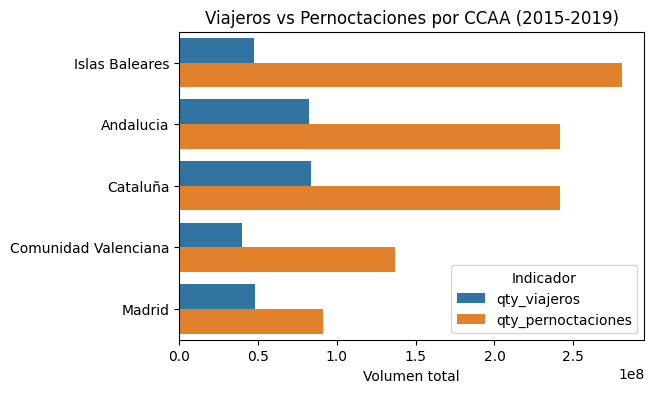

In [15]:
# Acumulado por CCAA
df_ccaa = (
    df_totales
    .groupby('ccaa')[['qty_viajeros', 'qty_pernoctaciones']]
    .sum()
    .sort_values('qty_pernoctaciones', ascending=False)
    .reset_index()
)

df_plot = df_ccaa.melt(
    id_vars='ccaa',
    value_vars=['qty_viajeros', 'qty_pernoctaciones'],
    var_name='tipo',
    value_name='valor'
)

plt.figure(figsize=(6,4))

sns.barplot(
    data=df_plot,
    y='ccaa',
    x='valor',
    hue='tipo'
)

plt.title('Viajeros vs Pernoctaciones por CCAA (2015-2019)')
plt.xlabel('Volumen total')
plt.ylabel('')
plt.legend(title='Indicador')

plt.show()

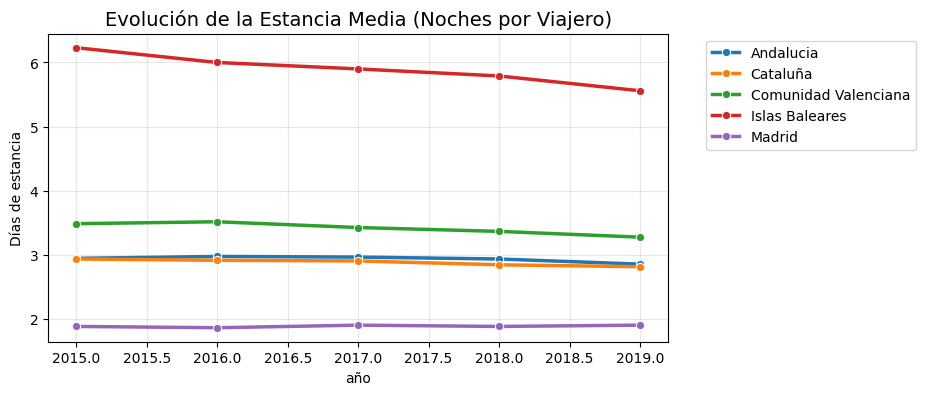

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.lineplot(data=dfmedias_año, x='año', y='Media_per_capita', hue='ccaa', marker='o', linewidth=2.5)

plt.title('Evolución de la Estancia Media (Noches por Viajero)', fontsize=14)
plt.ylabel('Días de estancia')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

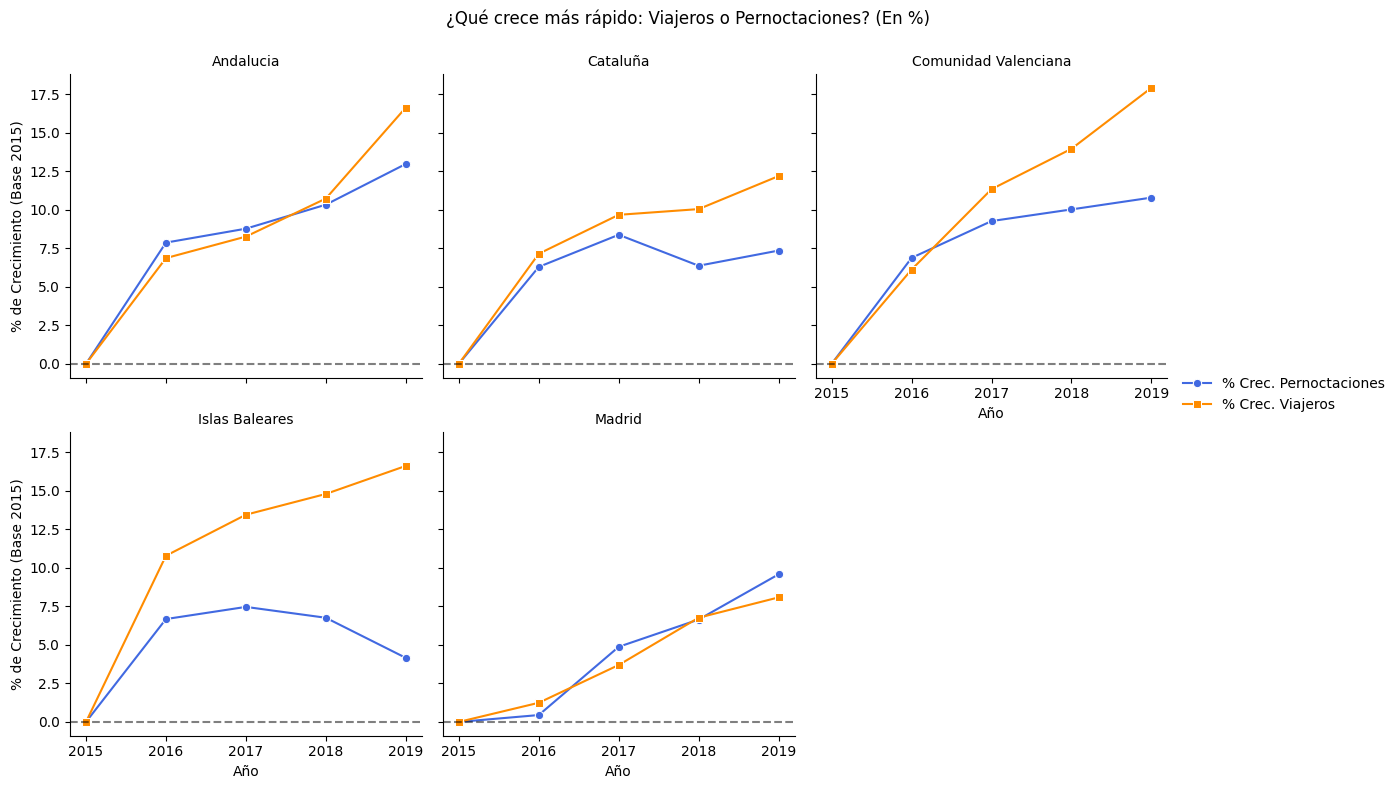

In [17]:
# Grafico de crecimiento relativo

# 1. Creamos las columnas de crecimiento porcentual respecto a 2015 por cada CCAA
dfmedias_año['pct_viajeros'] = dfmedias_año.groupby('ccaa')['qty_viajeros'].transform(lambda x: (x / x.iloc[0] - 1) * 100)
dfmedias_año['pct_pernoctaciones'] = dfmedias_año.groupby('ccaa')['qty_pernoctaciones'].transform(lambda x: (x / x.iloc[0] - 1) * 100)

# 2. Reutilizamos tu estructura de FacetGrid que tanto te ha gustado
g = sns.FacetGrid(dfmedias_año, col="ccaa", col_wrap=3, height=4)

# Dibujamos las dos líneas de porcentaje
g.map(sns.lineplot, "año", "pct_pernoctaciones", marker="o", color="royalblue", label="% Crec. Pernoctaciones")
g.map(sns.lineplot, "año", "pct_viajeros", marker="s", color="darkorange", label="% Crec. Viajeros")

# Añadimos una línea horizontal en el 0 para que se vea claro el punto de partida
g.map(plt.axhline, y=0, color='black', ls='--', alpha=0.5)

g.add_legend()
g.set_axis_labels("Año", "% de Crecimiento (Base 2015)")
g.set_titles("{col_name}")

plt.subplots_adjust(top=0.9)
g.fig.suptitle('¿Qué crece más rápido: Viajeros o Pernoctaciones? (En %)')
plt.show()